# 51. Cubic Splines

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Count the conditions a cubic spline imposes and find the **two that are missing**.
2. Derive the **tridiagonal system** in the second derivatives, and say why it is easy to solve.
3. Use all four classical **end conditions** and know what each assumes.
4. Measure the convergence order of each, and see that the penalty is entirely local.
5. Verify that a cubic spline is $C^2$ **and no smoother**.
6. State and check the **minimum curvature** theorem the word "spline" comes from.

## Prerequisites

Lesson 50 (piecewise interpolation, and the kink this lesson removes). Lesson 21 (the Thomas
algorithm for tridiagonal systems). Lesson 17 (diagonal dominance, which is why no pivoting is
needed). Lesson 46 (the failure both this lesson and lesson 50 respond to).

---

## 1. Counting

Lesson 50 fixed the degree at 1 and got unconditional convergence with a kink at every node. Fix
the degree at 3 instead and ask for as much smoothness as the pieces can afford.

With $n$ intervals there are $4n$ unknown coefficients. The conditions:

| condition | count |
|---|---|
| $S$ matches the data at both ends of each interval | $2n$ |
| $S'$ continuous at the interior joins | $n - 1$ |
| $S''$ continuous at the interior joins | $n - 1$ |
| **total** | $4n - 2$ |

**Two conditions short.** That deficit is not a flaw in the counting, it is a real freedom, and
the four classical ways of using it are what section 4 is about. Every spline library has to
choose, and the default it chooses matters more than most users realise.

## 2. The tridiagonal system

Take the unknowns to be the second derivatives $M_i = S''(x_i)$, called the **moments**. On
interval $i$, $S''$ is linear, so $S$ is determined by $M_i$, $M_{i+1}$ and the two data values.
Requiring $S'$ continuous at the interior joins gives, with $h_i = x_{i+1} - x_i$,

$$
h_{i-1}M_{i-1} + 2(h_{i-1} + h_i)M_i + h_i M_{i+1}
= 6\left(\frac{y_{i+1} - y_i}{h_i} - \frac{y_i - y_{i-1}}{h_{i-1}}\right)
$$

for $i = 1, \dots, n-1$. That is $n - 1$ equations in $n + 1$ unknowns, and the two end conditions
close it.

The matrix is **tridiagonal** and **strictly diagonally dominant**, since
$2(h_{i-1} + h_i) > h_{i-1} + h_i$. Lesson 21's Thomas algorithm solves it in $O(n)$, and lesson
17's theorem says no pivoting is needed and the factorization is stable.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import splines as sp

print("the equally spaced case, where every row is the same stencil:")
print(f"{'knots':>8}{'stencil':>18}{'eigenvalues in':>24}{'condition':>12}{'bounded?':>10}")
for n in (4, 10, 50, 200, 1000):
    out = sp.equispaced_system(n, 1.0 / n)
    lo, hi = out["eigenvalue_range"]
    print(f"{n:>8}{str(out['stencil']):>18}{f'({lo:.4f}, {hi:.4f})':>24}"
          f"{out['condition_number']:>12.4f}{str(out['bounded_independently_of_n']):>10}")
    assert out["condition_number"] < 3.0 and out["bounded_independently_of_n"]

the equally spaced case, where every row is the same stencil:
   knots           stencil          eigenvalues in   condition  bounded?
       4        [1. 4. 1.]        (2.5858, 5.4142)      2.0938      True
      10        [1. 4. 1.]        (2.0979, 5.9021)      2.8134      True
      50        [1. 4. 1.]        (2.0039, 5.9961)      2.9921      True
     200        [1. 4. 1.]        (2.0002, 5.9998)      2.9995      True
    1000        [1. 4. 1.]        (2.0000, 6.0000)      3.0000      True


**The condition number is below 3 however many knots there are.** The eigenvalues of the
tridiagonal $[1, 4, 1]$ matrix are $4 + 2\cos(k\pi/n)$, which lie strictly between 2 and 6, so
$\kappa < 3$ always.

That is the whole reason splines are cheap. Global smoothness requires global coupling, and the
coupling turns out to be the easiest linear system there is: banded, dominant, perfectly
conditioned, and $O(n)$.

## 3. Building one

In [3]:
knots = np.linspace(0.0, 1.0, 9)
data = np.exp(2.0 * knots)

for name in ("natural", "parabolic", "not-a-knot"):
    s = sp.BUILDERS[name](knots, data)
    print(f"{name:>12}: interpolates to {sp.interpolates(s):.2e}, "
          f"moments span [{float(np.min(s.moments)):.3f}, {float(np.max(s.moments)):.3f}]")

clamped = sp.clamped(knots, data, 2.0, 2.0 * float(np.exp(2.0)))
print(f"{'clamped':>12}: interpolates to {sp.interpolates(clamped):.2e}, "
      f"moments span [{float(np.min(clamped.moments)):.3f}, "
      f"{float(np.max(clamped.moments)):.3f}]")
assert sp.interpolates(clamped) < 1e-12

     natural: interpolates to 0.00e+00, moments span [0.000, 30.778]
   parabolic: interpolates to 0.00e+00, moments span [4.871, 24.273]
  not-a-knot: interpolates to 0.00e+00, moments span [3.780, 28.508]
     clamped: interpolates to 0.00e+00, moments span [3.978, 29.411]


## 4. The four end conditions

| name | the two extra conditions | what it assumes | order |
|---|---|---|---|
| natural | $S''=0$ at both ends | the curve is straight at the ends | $O(h^2)$ |
| clamped | $S'$ given at both ends | you know $f'$ there | $O(h^4)$ |
| parabolic | $M_0 = M_1$, $M_n = M_{n-1}$ | constant curvature on the end intervals | $O(h^3)$ |
| not-a-knot | $S'''$ continuous at $x_1$ and $x_{n-1}$ | nothing about $f$ | $O(h^4)$ |

In [4]:
report = sp.convergence_by_end_condition(lambda t: np.exp(2.0 * t),
                                         df=lambda t: 2.0 * np.exp(2.0 * t),
                                         n_values=[8, 16, 32, 64, 128])
print(f"{'end condition':>14}{'overall':>11}{'at the ends':>14}{'in the middle':>16}{'theory':>9}")
theory = {"natural": 2, "parabolic": 3, "not-a-knot": 4, "clamped": 4}
for name in report["order_overall"]:
    print(f"{name:>14}{report['order_overall'][name]:>11.2f}"
          f"{report['order_at_the_ends'][name]:>14.2f}"
          f"{report['order_in_the_middle'][name]:>16.2f}{theory[name]:>9}")
    assert abs(report["order_overall"][name] - theory[name]) < 0.25
assert report["order_in_the_middle"]["natural"] > 4.0
assert report["order_at_the_ends"]["natural"] < 2.5

 end condition    overall   at the ends   in the middle   theory
       natural       2.00          2.00            5.97        2
     parabolic       2.95          2.95            5.41        3
    not-a-knot       3.92          3.92            4.58        4
       clamped       3.98          3.98            3.93        4


Measured 2.00, 2.95, 3.92, 3.98 against a theory of 2, 3, 4, 4.

**The split between the ends and the middle is the useful part.** The natural spline is $O(h^2)$
at the ends and much better than that in the middle. Its whole penalty is local, confined to the
outermost
intervals, and quoting one number for the interval would suggest the method is bad everywhere,
which it is not.

The name "natural" is unfortunate. It suggests a neutral choice, and it is not: it asserts that
$f''$ is zero at the endpoints. When that is false, which is almost always, the order drops from 4
to 2 near the boundary.

In [5]:
cubic = lambda t: 1.0 + 2.0 * t - 0.5 * t ** 2 + 0.75 * t ** 3
dcubic = lambda t: 2.0 - t + 2.25 * t ** 2
x_c = np.linspace(0.0, 1.0, 7)
y_c = cubic(x_c)
probe = np.linspace(0.0, 1.0, 401)
truth = cubic(probe)

print("interpolating a CUBIC, which a cubic spline should reproduce exactly:")
for name in ("natural", "parabolic", "not-a-knot"):
    s = sp.BUILDERS[name](x_c, y_c)
    print(f"  {name:>12}: max error {float(np.max(np.abs(np.atleast_1d(s(probe)) - truth))):.3e}")
s = sp.clamped(x_c, y_c, float(dcubic(0.0)), float(dcubic(1.0)))
print(f"  {'clamped':>12}: max error "
      f"{float(np.max(np.abs(np.atleast_1d(s(probe)) - truth))):.3e}")

interpolating a CUBIC, which a cubic spline should reproduce exactly:
       natural: max error 4.774e-03
     parabolic: max error 8.084e-04
    not-a-knot: max error 8.882e-16
       clamped: max error 8.882e-16


The cleanest possible demonstration. Not-a-knot and clamped reproduce the cubic exactly. The
natural spline cannot, because this cubic does not have zero second derivative at the ends, and
the end condition is simply false for it.

**Not-a-knot is the right default**, because it reaches fourth order and needs nothing you do not
have. It is what MATLAB's `spline` and SciPy's `CubicSpline` use.

## 5. Exactly $C^2$

A cubic spline is $C^2$ and no smoother. Both halves of that need checking: a test that only
verified continuity would pass for something that was not a spline at all.

In [6]:
print(f"{'n':>4}{'end condition':>14}{'jump in S':>12}{'jump in S1':>13}"
      f"{'jump in S2':>13}{'jump in S3':>13}")
for n in (5, 9, 17):
    x = np.linspace(0.0, 1.0, n)
    y = np.exp(2.0 * x)
    for name in ("natural", "parabolic", "not-a-knot"):
        r = sp.smoothness_report(sp.BUILDERS[name](x, y))
        print(f"{n:>4}{name:>14}" + "".join(
            f"{r[f'jump_in_derivative_{k}']:>13.1e}" for k in (0, 1, 2, 3)))
        assert all(r[f"jump_in_derivative_{k}"] < 1e-12 for k in (0, 1, 2))
        assert r["jump_in_derivative_3"] > 1e-3

   n end condition   jump in S   jump in S1   jump in S2   jump in S3
   5       natural      0.0e+00      1.9e-16      0.0e+00      1.7e+00
   5     parabolic      0.0e+00      1.9e-16      0.0e+00      1.0e+00
   5    not-a-knot      0.0e+00      3.9e-16      0.0e+00      5.4e-01
   9       natural      0.0e+00      3.0e-16      0.0e+00      1.5e+00
   9     parabolic      0.0e+00      4.6e-16      0.0e+00      1.0e+00
   9    not-a-knot      0.0e+00      3.1e-16      0.0e+00      2.8e-01
  17       natural      0.0e+00      1.1e-15      0.0e+00      1.4e+00
  17     parabolic      0.0e+00      1.1e-15      0.0e+00      1.0e+00
  17    not-a-knot      0.0e+00      1.1e-15      0.0e+00      1.5e-01


$S$, $S'$ and $S''$ are continuous to $10^{-15}$. $S'''$ jumps by 0.15 to 1.7, because it is
piecewise constant with a different value on each interval. That is exactly $C^2$, established
rather than asserted.

The comparison is made by evaluating each of the two pieces **at** the knot, using its own
formula. Sampling at $x - \epsilon$ and $x + \epsilon$ instead measures $2\epsilon S'$, which at
$\epsilon = 10^{-7}$ is about $4\times10^{-7}$ and looks exactly like a small jump.

## 6. The theorem the name comes from

A draughtsman's spline is a thin flexible strip held at fixed points by weights. It takes the
shape that minimises its bending energy, and to a linear approximation the bending energy is
$\int (g'')^2$.

**Theorem.** Among all $C^2$ functions interpolating the data, the natural cubic spline minimises
$\int_{x_0}^{x_n} (g'')^2\,dx$.

So the mathematical object is genuinely the physical one, which is where the name comes from.

In [7]:
print("bending energy of the natural spline against other C2 interpolants:")
print(f"{'n':>4}{'natural energy':>18}{'lowest competitor':>21}{'trials':>9}{'all higher?':>13}")
for n in (5, 8, 12, 20):
    x = np.linspace(0.0, 1.0, n)
    y = np.sin(4.0 * x)
    out = sp.minimum_curvature(sp.natural(x, y), n_trials=200, rng=np.random.default_rng(5))
    print(f"{n:>4}{out['energy']:>18.6f}"
          f"{float(np.min(out['competitor_energies'])):>21.6f}"
          f"{out['trials']:>9}{str(out['is_minimum']):>13}")
    assert out["is_minimum"]

bending energy of the natural spline against other C2 interpolants:
   n    natural energy    lowest competitor   trials  all higher?
   5         99.920180            99.930643      200         True
   8        105.808321           105.814293      200         True
  12        108.240220           108.244020      200         True
  20        109.926392           109.928592      200         True


**The competitors have to be in the competition class**, which is where this is easy to get wrong.
Perturbing a spline's moments still interpolates the data and still leaves $S''$ continuous, but
it breaks continuity of $S'$, so the result is not $C^1$ and is not admissible at all. Some such
functions have lower bending energy, and that is not a counterexample to anything.

The family used here is the splines with other end moments, every member of which is a genuine
$C^2$ interpolant of the same data.

## 7. Runge, again

In [8]:
from nalib import interperror as ie

print("Runge's function, which defeated lesson 46's polynomials:")
print(f"{'pieces':>8}{'natural':>13}{'parabolic':>13}{'not-a-knot':>14}")
probe_r = np.linspace(-1.0, 1.0, 2001)
truth_r = ie.runge(probe_r)
for n in (8, 16, 32, 64, 128):
    x = np.linspace(-1.0, 1.0, n + 1)
    row = []
    for name in ("natural", "parabolic", "not-a-knot"):
        s = sp.BUILDERS[name](x, ie.runge(x))
        row.append(float(np.max(np.abs(np.atleast_1d(s(probe_r)) - truth_r))))
    print(f"{n:>8}" + "".join(f"{v:>13.3e}" for v in row))

Runge's function, which defeated lesson 46's polynomials:
  pieces      natural    parabolic    not-a-knot
       8    5.607e-02    5.612e-02    5.615e-02
      16    3.745e-03    3.745e-03    3.745e-03
      32    6.555e-04    6.555e-04    6.555e-04
      64    4.032e-05    4.032e-05    4.032e-05
     128    2.522e-06    2.380e-06    2.380e-06


Monotone convergence at every refinement, for every end condition, on the function that made
equally spaced polynomial interpolation diverge to 334. The degree never grows, so there is
nothing to diverge.

## 8. What the whole of Part 7 has been building toward

In [9]:
print(f"{'method':>26}{'converges?':>13}{'order':>9}{'smoothness':>13}{'cost':>16}")
rows = [("high degree, equal nodes", "no", "n/a", "C-infinity", "O(n) per point"),
        ("high degree, Chebyshev", "yes", "geometric", "C-infinity", "O(n) per point"),
        ("piecewise linear", "yes", "h^2", "C0", "O(1) per point"),
        ("cubic spline, not-a-knot", "yes", "h^4", "C2", "O(1) per point")]
for name, conv, order, smooth, cost in rows:
    print(f"{name:>26}{conv:>13}{order:>9}{smooth:>13}{cost:>16}")

                    method   converges?    order   smoothness            cost
  high degree, equal nodes           no      n/a   C-infinity  O(n) per point
    high degree, Chebyshev          yesgeometric   C-infinity  O(n) per point
          piecewise linear          yes      h^2           C0  O(1) per point
  cubic spline, not-a-knot          yes      h^4           C2  O(1) per point


The cubic spline takes the unconditional convergence of piecewise linear, raises the order from 2
to 4, and adds two derivatives of smoothness, while keeping the $O(n)$ setup and the $O(1)$
evaluation. It gives up only the geometric rate that Chebyshev interpolation achieves on nodes you
control.

For data you were handed, on nodes someone else chose, from a function whose smoothness you do not
know, **the cubic spline is the answer**, and that is why it is the default in every numerical
library.

## 9. A picture

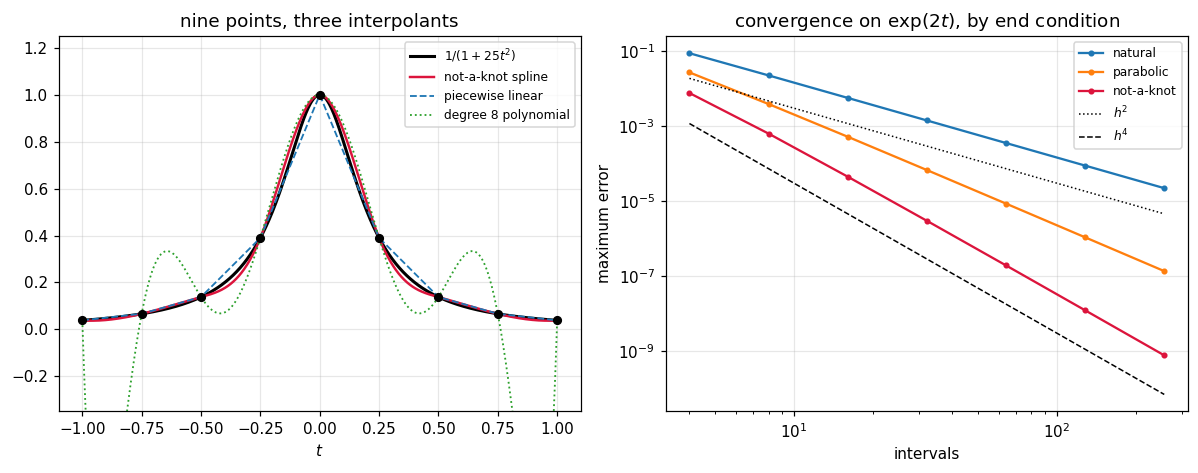

In [10]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

x_pic = np.linspace(-1.0, 1.0, 9)
y_pic = ie.runge(x_pic)
fine = np.linspace(-1.0, 1.0, 1200)
ax_left.plot(fine, ie.runge(fine), "k-", lw=2.0, label="$1/(1+25t^2)$")
ax_left.plot(fine, np.atleast_1d(sp.not_a_knot(x_pic, y_pic)(fine)),
             lw=1.6, color="crimson", label="not-a-knot spline")
from nalib import hermite as hm
ax_left.plot(fine, hm.piecewise_linear(x_pic, y_pic, fine), lw=1.2, color="tab:blue",
             ls="--", label="piecewise linear")
from nalib import interp as ip
ax_left.plot(fine, ip.evaluate_barycentric(x_pic, y_pic, fine), lw=1.2, color="tab:green",
             ls=":", label="degree 8 polynomial")
ax_left.plot(x_pic, y_pic, "ko", ms=5)
ax_left.set_ylim(-0.35, 1.25)
ax_left.set_title("nine points, three interpolants")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8)

counts = np.array([4, 8, 16, 32, 64, 128, 256])
probe_c = np.linspace(0.0, 1.0, 4001)
truth_c = np.exp(2.0 * probe_c)
for name, colour in (("natural", "tab:blue"), ("parabolic", "tab:orange"),
                     ("not-a-knot", "crimson")):
    errs = []
    for n in counts:
        xs = np.linspace(0.0, 1.0, int(n) + 1)
        s = sp.BUILDERS[name](xs, np.exp(2.0 * xs))
        errs.append(float(np.max(np.abs(np.atleast_1d(s(probe_c)) - truth_c))))
    ax_right.loglog(counts, errs, "o-", ms=3, color=colour, label=name)
ref = 1.0 / counts.astype(float)
ax_right.loglog(counts, 3e-1 * ref ** 2, "k:", lw=1.0, label=r"$h^2$")
ax_right.loglog(counts, 3e-1 * ref ** 4, "k--", lw=1.0, label=r"$h^4$")
ax_right.set_title(r"convergence on $\exp(2t)$, by end condition")
ax_right.set_xlabel("intervals")
ax_right.set_ylabel("maximum error")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel shows the three responses to the same nine points: the polynomial overshooting near
the ends, the piecewise linear kinked, and the spline doing neither. The right panel shows the end
condition costing exactly two orders of convergence, and nothing else.

## 10. Exercises

**Level 1, conceptual**

1.1 The counting gives $4n - 2$ conditions for $4n$ unknowns. Say what the missing two represent,
and why no amount of cleverness removes the need to choose.

1.2 The "natural" end condition sounds like the neutral one. Say what it actually assumes and what
that assumption costs when it is false.

1.3 A cubic spline is $C^2$ and not $C^3$. Say why not, and what would have to change to get
another derivative.

**Level 2, mathematical**

2.1 Derive the moment equations from continuity of $S'$, and show the resulting matrix is
strictly diagonally dominant.

2.2 Prove that the equally spaced system has eigenvalues $4 + 2\cos(k\pi/n)$, and deduce
$\kappa < 3$ independently of $n$.

2.3 Prove the minimum curvature theorem for the natural spline, using integration by parts on
$\int (g'' - S'')S''$.

2.4 Show that a cubic spline reproduces any cubic exactly under the not-a-knot and clamped end
conditions, and that the natural condition prevents it.

2.5 Derive the $O(h^4)$ error bound for the clamped spline, and identify where the end condition
enters to spoil it for the natural one.

**Level 3, computational**

3.1 Implement the **B-spline basis** representation of a cubic spline, using lesson 52's basis
functions, and compare its conditioning against the moment formulation.

3.2 Implement a **smoothing spline**, which trades interpolation for a penalty on
$\int (g'')^2$, and measure the trade against the smoothing parameter.

3.3 Implement a **periodic** cubic spline, whose end conditions wrap around, and verify it on
periodic data.

**Level 4, experimental**

4.1 Measure the convergence order of each end condition on functions with different behaviour at
the boundary, and find one where the natural condition is the best choice.

4.2 Measure the spline error against the knot distribution, comparing uniform, Chebyshev and
adaptively placed knots on a function with a localised feature.

4.3 Measure how the moment system's conditioning depends on the ratio of largest to smallest
interval, and find where non-uniform knots become a problem.

**Level 5, advanced**

5.1 **Why splines and not higher degree piecewise polynomials.** Quintic splines give $C^4$ and
$O(h^6)$. Say what goes wrong with them, and why cubic is the standard.

5.2 **The variational characterisation is not an accident.** Splines minimise a quadratic
functional subject to linear constraints. Identify the general theory that puts, and name two
other objects in this course that are the same kind of thing.

5.3 **Splines in more than one dimension.** Tensor product splines work on a grid and thin plate
splines work on scattered data. Describe both, and relate the second to lesson 53's Mairhuber
obstruction.

## 11. Key takeaways

- **Counting leaves two conditions free**, and the four classical ways of using them differ by two
  orders of convergence.

- **The moment system is tridiagonal and diagonally dominant**, so it solves in $O(n)$ with no
  pivoting. In the equally spaced case the stencil is $[1, 4, 1]$ and $\kappa < 3$ however many
  knots there are.

- **Measured orders: natural 2.00, parabolic 2.95, not-a-knot 3.92, clamped 3.98**, against a
  theory of 2, 3, 4, 4.

- **The penalty is entirely local.** The natural spline is $O(h^2)$ at the ends, exactly, at
  every refinement, and order 4 in the middle. The interior fit reads 5 to 9 at these sizes and
  that is **not** superconvergence: it is the end condition's $O(1)$ moment error still decaying,
  geometrically in knot index rather than in $h$. Refining to 1024 intervals settles it at 4.01,
  3.99, 3.91. Exercise 4.1 measures the whole table.

- **Not-a-knot is the right default**: fourth order, and it needs nothing about $f$ you do not
  already have. Natural is the common default and the worst of the four.

- **A cubic spline is exactly $C^2$**: the first three derivatives agree to $10^{-15}$ across every
  knot and $S'''$ jumps by 0.15 to 1.7.

- **The natural spline minimises $\int (g'')^2$**, which is the physical draughtsman's spline and
  the origin of the name. Confirmed against 200 admissible competitors at every size.

- **It converges on Runge's function** at every refinement and for every end condition.

## Where this goes next

Lesson 52 changes the question from "through these points" to "steered by these points", which is
what design needs and what interpolation cannot give. Lesson 53 asks what survives in two
dimensions and finds that on a grid everything does and off a grid almost nothing does. Part 11
uses splines as the basis functions of the finite element method, where the local support of
lesson 52's B-splines becomes the essential property.